# Dimensionality Reduction

**If You Are a Google Colab User**

If you use Google Colab, you can uncomment the following cell to mount your Google Drive to Colab.
After that, Colab can read and write files and data in your Google Drive.

Please change the current directory to the folder containing your notebook and data folder.
For example, I save my Colab files and data in the following location.

In [1]:
#from google.colab import drive
#drive.mount('/content/drive')

#%cd /content/drive/MyDrive/Colab\ Notebooks

**Set Up the Notebook**

In [2]:
# import libraries and modules to be used
import numpy as np 
np.random.seed(12345)
np.set_printoptions(precision=4, suppress=True)

import pandas as pd

%matplotlib inline
import matplotlib.pyplot as plt
plt.rc("figure", figsize=(9, 6))

import seaborn as sns

import scipy as sp
from scipy import stats # we'll use the stats module of scipy

# to display multiple outputs in one cell
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"


## A Simple PCA Example

This section uses a simple two-dimensional dataset to show the main idea of PCA before applying it to a larger real dataset. We examine SVD, EVD, and PCA as different mathematical views of the same task: finding the directions where the data varies the most and using those directions as new axes.

### Data

The scale matrix is:
 [[1.  0. ]
 [0.  0.3]]

The rotation matrix is:
 [[ 0.866 -0.5  ]
 [ 0.5    0.866]]

The transform matrix is:
 [[ 0.866  -0.15  ]
 [ 0.5     0.2598]]


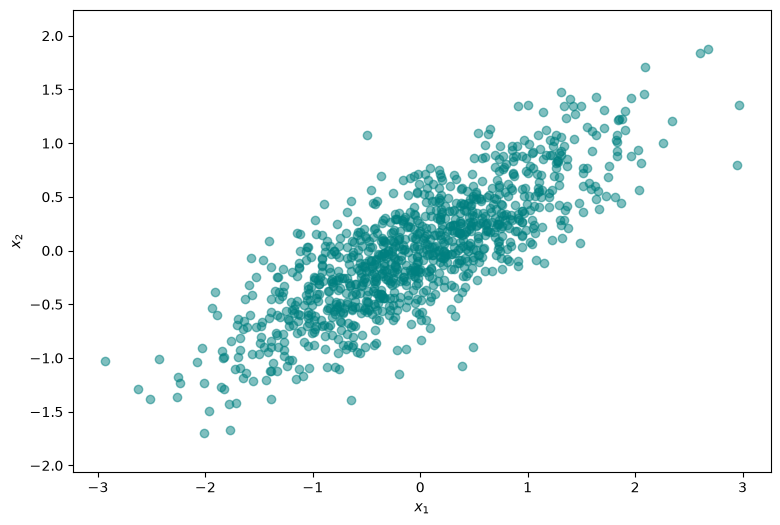

In [3]:
# This step generates data for this numerical example. You can skip the technical details of this step.
# Just imagine that the dataset is a sample of two attributes with 1,000 observations.

X = np.random.randn(1000,2) # Generate a two-dimensional dataset with 1,000 observations randomly generated from the standard normal distribution.
scale=np.array([[1,0], [0,0.3]])  # Scale matrix: the standard deviations of the two attributes become 1 and 0.3.
print(f'The scale matrix is:\n {scale}\n')
rotate=np.array([[np.sqrt(3),-1], [1,np.sqrt(3)]]) / 2 # Counterclockwise rotation by 30 degrees: [[cos(theta), -sin(theta)],[sin(theta), cos(theta)]].
#rotate=np.array([[1,-1], [1,1]]) / np.sqrt(2) # Counterclockwise rotation by 45 degrees: [[cos(theta), -sin(theta)],[sin(theta), cos(theta)]].
print(f'The rotation matrix is:\n {rotate}\n')
transform = rotate @ scale # Transformation matrix that scales and rotates the original dataset.
print(f'The transform matrix is:\n {transform}')
X=(transform @ X.T).T # Apply the transformation to the original dataset.
plt.scatter(X[:,0],
            X[:,1],
            color='teal',
            alpha=0.5)
plt.axis('equal')
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.show();

### Sample Statistics

In [4]:
# sample mean of the two features
X.mean(axis=0) 

array([-0.0366, -0.0047])

In [5]:
# sample variance
X.var(axis=0,ddof=1)

array([0.7922, 0.3207])

In [6]:
# Sample covariance
np.cov(X.T)

# The covariance matrix shows that the two attributes are positively correlated.

array([[0.7922, 0.4049],
       [0.4049, 0.3207]])

### Singular Value Decomposition (SVD)

In [7]:
# Let's perform the singular value decomposition (SVD) for the zero-centered sample X
U,S,V=np.linalg.svd((X-X.mean(axis=0))) # SVD is a matrix factorization technique that decomposes a matrix into three matrices: U, S, and V. In this case, we are performing SVD on the zero-centered sample X (i.e., X with its mean subtracted). 
print(f'The matrix of right singular vectors is:\n {V.T}\n') # You may find that the matrix of right singular vectors is the rotation matrix (v0, v1).
print(f'The sample variances in the directions of the singular vectors are:\n {np.square(S)/(len(X)-1)}') # The square of each singular value divided by (sample size - 1) equals the sample variance in the corresponding direction of the singular vector.

The matrix of right singular vectors is:
 [[ 0.867  -0.4984]
 [ 0.4984  0.867 ]]

The sample variances in the directions of the singular vectors are:
 [1.0249 0.0879]


### Eigenvalue Decomposition (EVD)

In [8]:
# We can perform eigenvalue decomposition (EVD) on the covariance matrix of X.T to obtain the same result.
L,F=np.linalg.eig(np.cov(X.T)) # Use the np.cov function to find the covariance matrix.

print(f'The matrix of eigenvectors is:\n {F}\n') # Eigenvectors

print(f'The vector of eigenvalues is:\n {L}\n') # Eigenvalues

The matrix of eigenvectors is:
 [[ 0.867  -0.4984]
 [ 0.4984  0.867 ]]

The vector of eigenvalues is:
 [1.0249 0.0879]



### Principal Component Analysis (PCA)

In [9]:
# Perform PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=2) # choose two principal components (d=2), d is no greater than min(rows of X, columns of X)
pca.fit(X-X.mean(axis=0)) # zero-centering X
print(pca.components_) # do you notice that the PC loadings (p1,p2) are the eigen vectors of X's covariance matrix?
print(pca.explained_variance_) # do you notice that the explained variance by PCs are the eigen values?

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",2
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD 

[[ 0.867   0.4984]
 [-0.4984  0.867 ]]
[1.0249 0.0879]


### Visualize the PCA Results
You may skip this section.

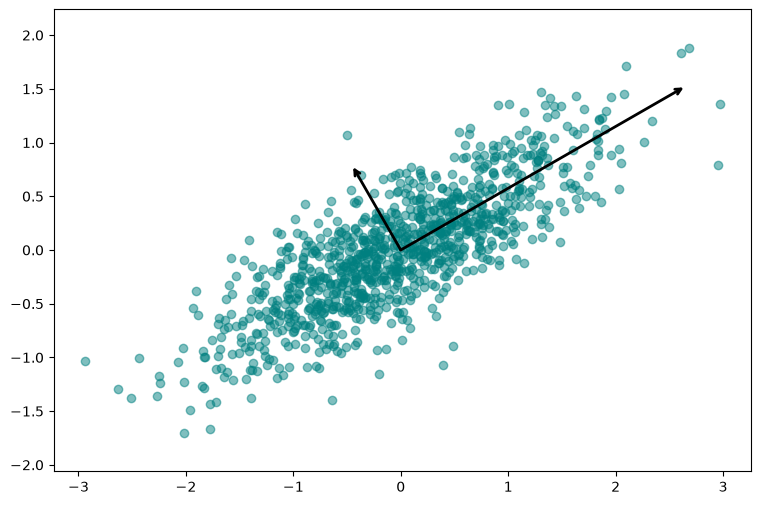

In [10]:
# You can skip this cell, but please take a look at the produced figure.

# Define arrows to represent vectors 
def draw_vector(v0, v1, ax=None): # [v0, v1] defines the starting and ending points of a vector.
    ax = ax or plt.gca()
    arrowprops=dict(arrowstyle='->',
                    linewidth=2,
                    shrinkA=0, shrinkB=0)
    ax.annotate('', v1, v0, arrowprops=arrowprops)


plt.scatter(X[:, 0], 
            X[:, 1], 
            color='teal',
            alpha=0.5) # Plot data X.
for length, vector in zip(pca.explained_variance_, pca.components_):
    v = vector * 3 * np.sqrt(length)
    draw_vector(pca.mean_, pca.mean_ + v)
plt.axis('equal')
plt.show();

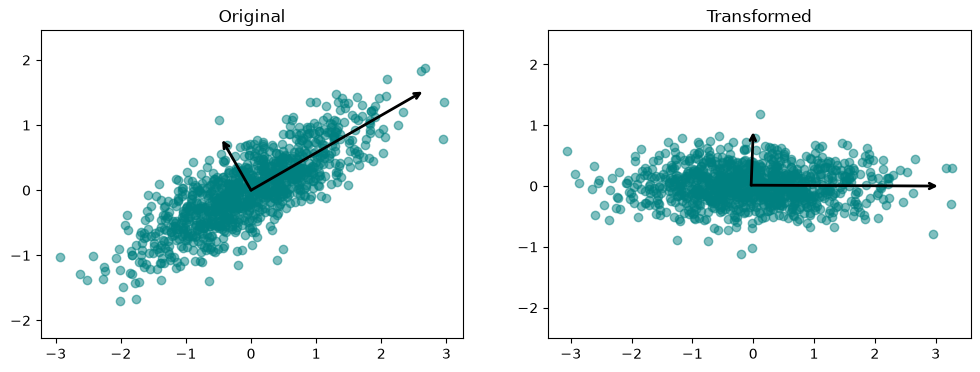

In [11]:
# You can skip the code of this cell, but please take a look at the produced figure

# Let's compare the origional data and transformed data

fig, axes = plt.subplots(1,2, figsize=(12,4))

# scatter plot of origional data
axes[0].axis('equal')
axes[0].scatter(X[:,0], 
                X[:,1],
                color='teal',
                alpha=0.5)
for length, vector in zip(pca.explained_variance_, pca.components_):
    draw_vector(pca.mean_, vector*3*np.sqrt(length), axes[0])
axes[0].set_title("Original")

# scatter plot of transformed data
Z=pca.transform(X) # apply pca transform
axes[1].axis('equal')
axes[1].scatter(Z[:,0], 
                Z[:,1],
                color='teal',
                alpha=0.5)
for length, vector in zip(np.var(Z,axis=0), [np.array([1.0,0.0]),np.array([0.0,1.0])]):
    draw_vector(np.mean(Z,axis=0), vector*3*np.sqrt(length), axes[1])
axes[1].set_title("Transformed")

plt.show();

[[0.867  0.4984]]
The variance explained by the first principal component is 92.10 %.


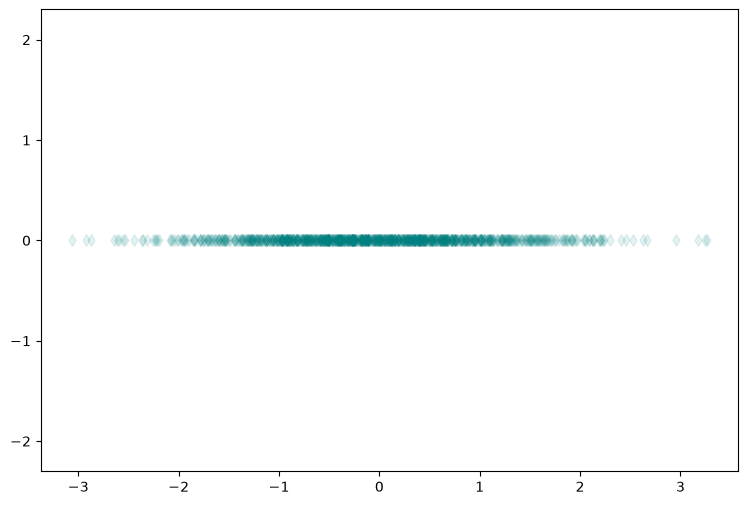

In [12]:
# Let's use one principal component
pca = PCA(n_components=1)
pca.fit(X-X.mean(axis=0))
X_pca = pca.transform(X) # transformed data
print(pca.components_) # the 1st principal component
print(f'The variance explained by the first principal component is {pca.explained_variance_ratio_[0]*100:.2f} %.')
plt.axis('equal')
plt.scatter(X_pca[:,0],
            np.zeros(1000), 
            marker="d", 
            color='teal',
            alpha=0.1)
plt.show();

## PCA: California Housing Dataset

This section applies the same PCA idea to a real dataset with multiple housing attributes. The goal is to standardize the features, use PCA to summarize the main patterns across those attributes, and interpret how much information is retained when we reduce the data to fewer principal components.

### Data Understanding and Preparation

In [13]:
# Import the California Housing dataset.
from sklearn.datasets import fetch_california_housing
CA_housing = fetch_california_housing()

In [14]:
# The dataset is stored as a dictionary.
# Let's check which keys are available in the dataset.
# 'data' contains the 8 attributes (columns of the raw data matrix),
# and 'target' contains the response variable, the median house value.
CA_housing.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])

In [15]:
print(CA_housing.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib:
https://lib.stat.cmu.edu/datasets/houses.zip

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per census
block group. A block g

In [16]:
# Let's create a dataframe that saves the 8 attributes
df = pd.DataFrame(CA_housing['data'],columns=CA_housing['feature_names'])
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


### Data Standardization

In [17]:
# Standardize the data so that each attribute has zero mean and unit variance.
from sklearn.preprocessing import StandardScaler

#scaler = StandardScaler()
#scaler.fit(df) # Compute the mean and standard deviation for centering and scaling.
#sd_df = scaler.transform(df) # Standardize df by centering and scaling. We perform PCA on sd_df.

sd_df=StandardScaler().fit_transform(df) # fit_transform(df) combines fitting the scaler and transforming the data by centering and scaling it.

### Principal Component Analysis (PCA)

In [18]:
from sklearn.decomposition import PCA
No_PC = 8 # define the number of principal components. Here we use No_PC = the total number of attributes in order to observe the contribution of every principal component. Feel free to choose smaller numbers

pca = PCA(n_components=No_PC)
pca.fit(sd_df) # fit the model on the normalized dataset (i.e., this step determines the loadings)
df_pca = pca.transform(sd_df) # apply dimensional reduction to the normalized data to obtain principal components

# fit_transform is the combination of .fit() and .transform(). Don't use fit_transform() on any test dataset
#df_pca=pca.fit_transform(sd_df) # fit the model on the normalized dataset and then transform the data to find principal components.

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",8
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD 

### Visualizing the Principal Components



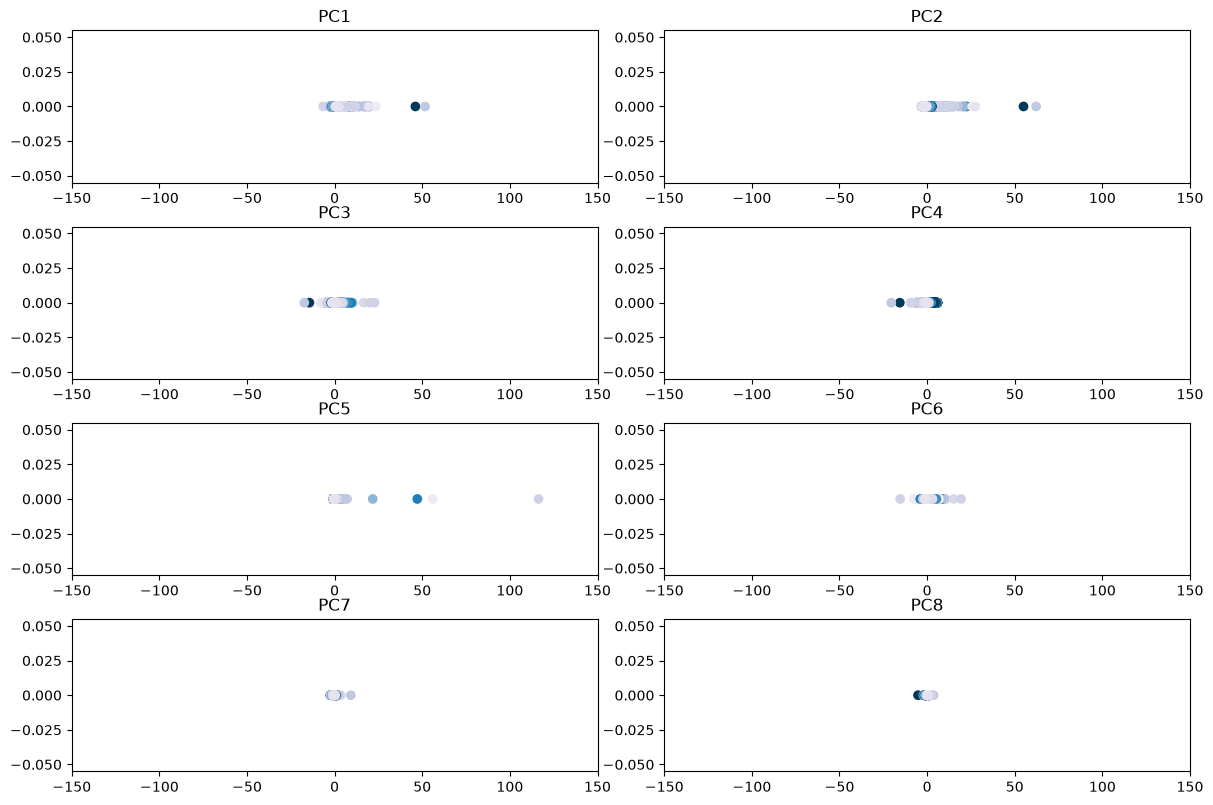

In [19]:
# Show a one-dimensional scatter plot for each principal component; the target value is represented by color.
fig, axs=plt.subplots(4,2, figsize=(12,8))
fig.tight_layout()
m=0
for i in range(4):
  for j in range(2):
    axs[i,j].scatter(df_pca[:,m],np.zeros(len(df_pca)),c=CA_housing['target'],cmap='PuBu')
    axs[i,j].set_title('PC%d'%(m+1))
    axs[i,j].set_xlim(-150,150)

    m+=1

plt.show();

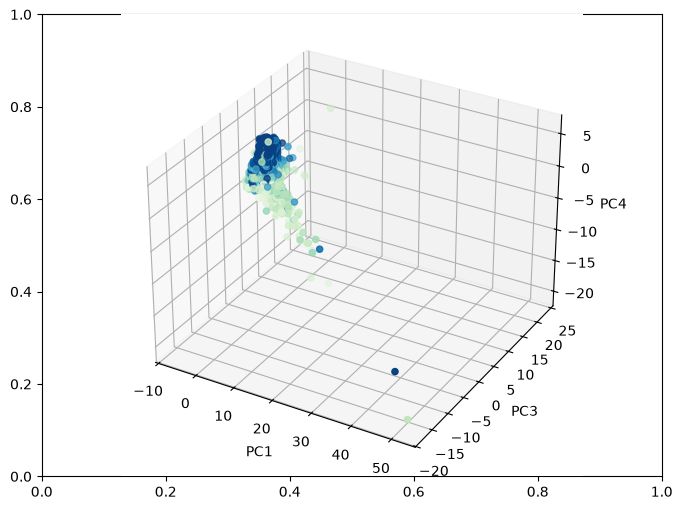

In [20]:
# plot the observations on three PCs.
#The color of the observations is median house value
#Can you differentiate median house values by looking at the first three components or any three components?
fig, ax = plt.subplots(1,1,figsize=(8,6))
# select three components by specifying their indices
i = 0
j = 2
k = 3
ax = fig.add_subplot(projection='3d')
ax.scatter(df_pca[:,i],df_pca[:,j],df_pca[:,k],c=CA_housing['target'],cmap='GnBu')
ax.set_xlabel('PC%d'%(i+1))
ax.set_ylabel('PC%d'%(j+1))
ax.set_zlabel('PC%d'%(k+1))

plt.show();

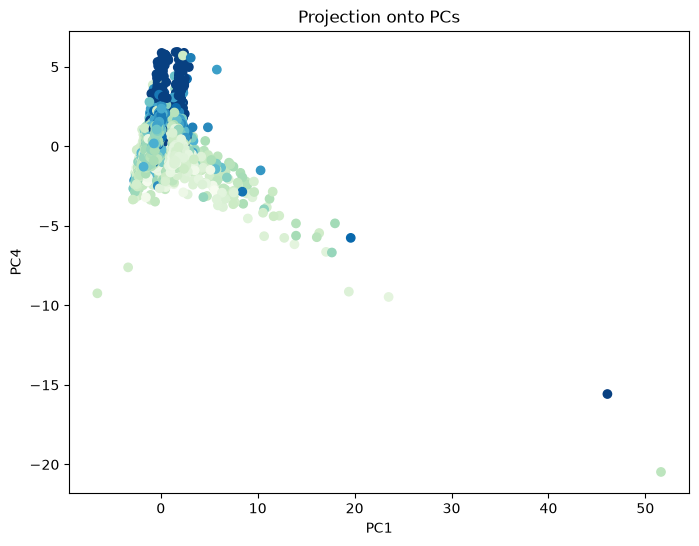

In [21]:
# visualize the projection of data onto two PCs
fig, ax = plt.subplots(1,1,figsize=(8,6))
i = 0
j = 3
ax.scatter(df_pca[:,i],df_pca[:,j],c=CA_housing['target'],cmap='GnBu')
plt.title('Projection onto PCs')
plt.xlabel('PC%d'%(i+1))
plt.ylabel('PC%d'%(j+1))
plt.colorbar
plt.show();

### Interpret the Principal Components

In [22]:
# the Principal components' loadings are stored as an attribute of the fitted PCA object (the ith row is the loadings for obtaining the ith principal component)
pca.components_.round(3)

array([[ 0.077,  0.007,  0.439,  0.4  , -0.172, -0.015,  0.568, -0.537],
       [ 0.23 , -0.261,  0.547,  0.502,  0.101,  0.003, -0.374,  0.422],
       [ 0.218, -0.628, -0.064, -0.192,  0.65 ,  0.158,  0.193, -0.181],
       [ 0.885,  0.11 ,  0.046, -0.338, -0.283, -0.005, -0.062, -0.06 ],
       [-0.003,  0.223,  0.03 ,  0.051,  0.008,  0.973, -0.023,  0.012],
       [ 0.15 ,  0.684,  0.095,  0.087,  0.675, -0.169, -0.042, -0.083],
       [ 0.169, -0.081, -0.531,  0.532, -0.032,  0.003, -0.432, -0.462],
       [ 0.242,  0.045, -0.459,  0.38 ,  0.013, -0.009,  0.554,  0.526]])

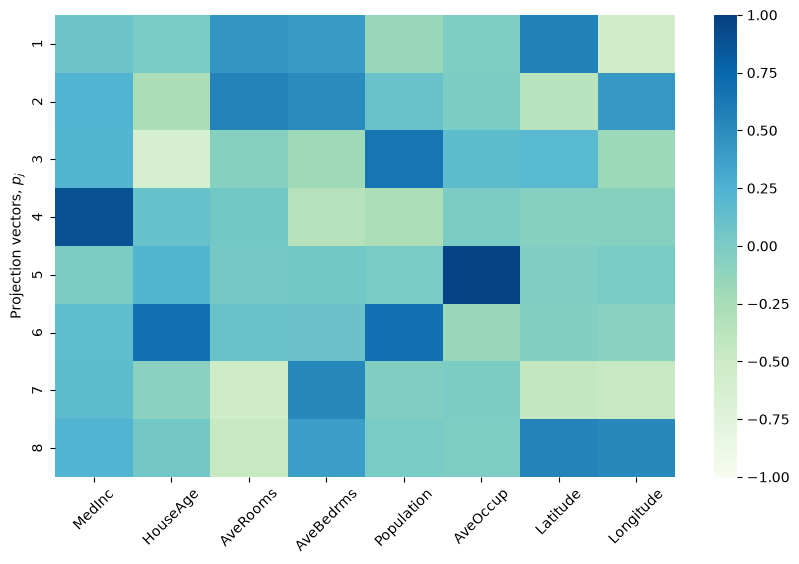

In [23]:
# we visualize the components
#The heatmap and the color bar tell the correlation between the various attributes and the principal component itself.
rel= pd.DataFrame(pca.components_.round(2),
                  columns=CA_housing['feature_names'])
fig, ax = plt.subplots(figsize=(10,6))

sns.heatmap(rel,
            annot=False,
            vmin=-1, 
            vmax=1, 
            center= 0,
            annot_kws={"size":8},
            cmap='GnBu',ax=ax)

ax.set_yticklabels(np.arange(1,No_PC+1))
plt.xticks(rotation=45)
plt.ylabel('Projection vectors, $p_j$')
plt.show();

### Variance Explained by the Principal Components

In [24]:
# the proportion of variances explained by PCs
pca.explained_variance_ratio_.round(3)

array([0.253, 0.235, 0.159, 0.129, 0.125, 0.082, 0.01 , 0.006])

In [25]:
# the proportion of cumulative variances explained by the first i principal componnets, for i=1, 2, ..., 13
X_var_ratio_cum=pca.explained_variance_ratio_.cumsum() # no.cumsum() returns the cumulative sum of the elements along a given axis
X_var_ratio_cum.round(3)

array([0.253, 0.489, 0.647, 0.776, 0.902, 0.984, 0.994, 1.   ])

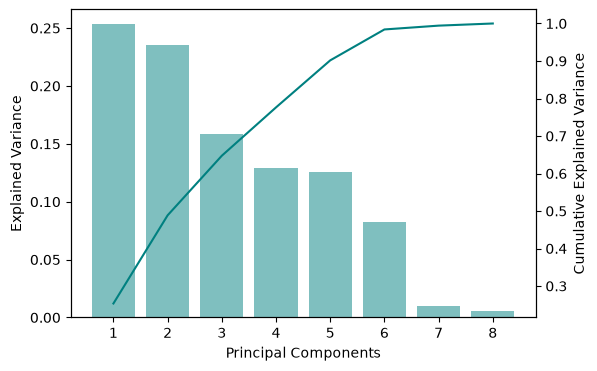

In [26]:
# Visualize the variance explained by different principal components
fig, ax = plt.subplots(1,1, figsize=(6,4))
# we use a bar chart to show the variance explained by each principal component
ax.bar(np.arange(1,No_PC+1,1), 
       pca.explained_variance_ratio_,
       color='teal',
       alpha=0.5)
ax.set_xticks(range(1,No_PC+1))
ax.set_xlabel('Principal Components')
ax.set_ylabel('Explained Variance')
# we use the line chart to show the cumulative variance explained by the top n principal components
ax2 = ax.twinx() # .twinx() creates the secondary axes by sharing the x axis
ax2.plot(range(1,No_PC+1),X_var_ratio_cum, color='teal')
ax2.set_ylabel('Cumulative Explained Variance')
plt.show();

The correlation matrix is:
               MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
MedInc      1.000000 -0.119034  0.326895  -0.062040    0.004834  0.018766   
HouseAge   -0.119034  1.000000 -0.153277  -0.077747   -0.296244  0.013191   
AveRooms    0.326895 -0.153277  1.000000   0.847621   -0.072213 -0.004852   
AveBedrms  -0.062040 -0.077747  0.847621   1.000000   -0.066197 -0.006181   
Population  0.004834 -0.296244 -0.072213  -0.066197    1.000000  0.069863   
AveOccup    0.018766  0.013191 -0.004852  -0.006181    0.069863  1.000000   
Latitude   -0.079809  0.011173  0.106389   0.069721   -0.108785  0.002366   
Longitude  -0.015176 -0.108197 -0.027540   0.013344    0.099773  0.002476   

            Latitude  Longitude  
MedInc     -0.079809  -0.015176  
HouseAge    0.011173  -0.108197  
AveRooms    0.106389  -0.027540  
AveBedrms   0.069721   0.013344  
Population -0.108785   0.099773  
AveOccup    0.002366   0.002476  
Latitude    1.000000  -0.924664  
Longit

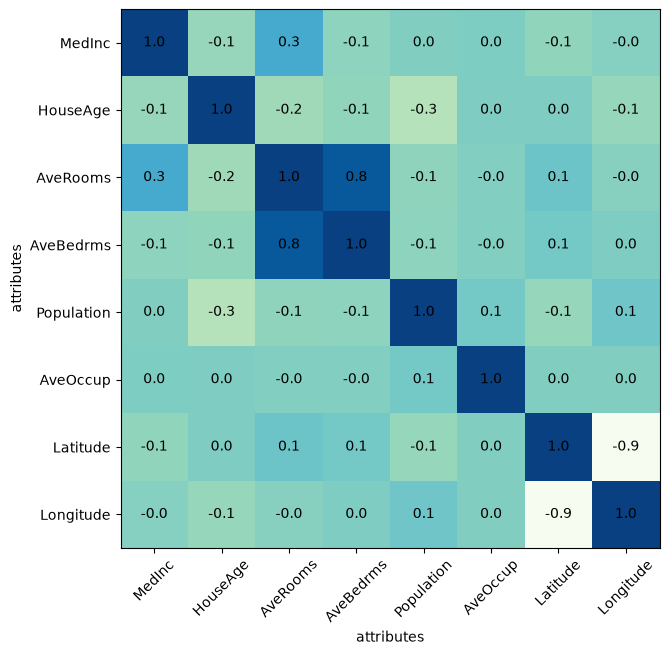

In [27]:
# correlation of attributes

df=pd.DataFrame(np.corrcoef(sd_df.T), columns=CA_housing['feature_names'],index=CA_housing['feature_names'])
print(f'The correlation matrix is:\n {df}')

fig, ax = plt.subplots(1,1, figsize=(7,7))
ax.imshow(df,cmap='GnBu')
ax.set_xlabel('attributes')
ax.set_ylabel('attributes')
ax.set_xticks(range(len(CA_housing['feature_names'])),labels=CA_housing['feature_names'],rotation=45)
ax.set_yticks(range(len(CA_housing['feature_names'])),labels=CA_housing['feature_names'],rotation=0)

for i in range(len(CA_housing['feature_names'])):
    for j in range(len(CA_housing['feature_names'])):
        text = ax.text(i, j, df.iloc[i, j].round(1),
                       ha="center", va="center", color="k")

# sns.heatmap is another way to create the heatmap
#sns.heatmap(np.corrcoef(sd_df.T),annot = True,vmin=-1, vmax=1, center= 0,cmap='seismic',ax=ax)
#plt.xlabel('attributes')
#plt.ylabel('attributes')

plt.show();


The correlation matrix of principal components are:
                   MedInc      HouseAge      AveRooms     AveBedrms  \
MedInc      1.000000e+00 -1.057746e-16 -3.903392e-17  1.776481e-16   
HouseAge   -1.057746e-16  1.000000e+00  2.867339e-16  9.293988e-17   
AveRooms   -3.903392e-17  2.867339e-16  1.000000e+00 -1.302096e-16   
AveBedrms   1.776481e-16  9.293988e-17 -1.302096e-16  1.000000e+00   
Population  1.907924e-16 -1.544977e-16  2.134164e-18  9.127270e-17   
AveOccup   -1.917684e-16 -3.906886e-16 -8.979634e-16  1.670073e-17   
Latitude   -6.492390e-16 -3.136678e-16  4.678499e-16 -3.791965e-16   
Longitude  -3.941184e-16 -2.117160e-15 -4.876801e-16 -5.240173e-17   

              Population      AveOccup      Latitude     Longitude  
MedInc      1.907924e-16 -1.917684e-16 -6.492390e-16 -3.941184e-16  
HouseAge   -1.544977e-16 -3.906886e-16 -3.136678e-16 -2.117160e-15  
AveRooms    2.134164e-18 -8.979634e-16  4.678499e-16 -4.876801e-16  
AveBedrms   9.127270e-17  1.670073e-17 -

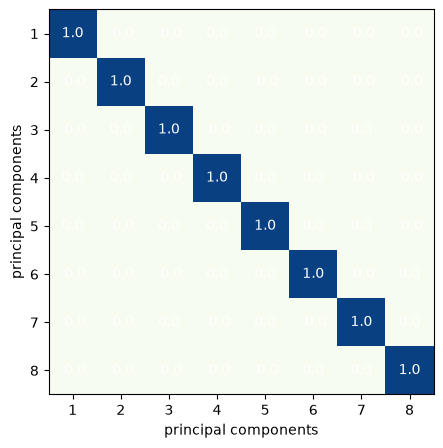

In [28]:
# correlation of principal components

df=pd.DataFrame(np.corrcoef(pca.transform(sd_df).T), columns=CA_housing['feature_names'],index=CA_housing['feature_names'])
print(f'The correlation matrix of principal components are:\n {df}')

fig, ax = plt.subplots(1,1, figsize=(5,5))
ax.imshow(df,cmap='GnBu')
plt.xlabel('principal components')
plt.ylabel('principal components')
ax.set_xticks(range(len(CA_housing['feature_names'])),labels=range(1,len(CA_housing['feature_names'])+1),rotation=0)
ax.set_yticks(range(len(CA_housing['feature_names'])),labels=range(1,len(CA_housing['feature_names'])+1),rotation=0)

for i in range(len(CA_housing['feature_names'])):
    for j in range(len(CA_housing['feature_names'])):
        text = ax.text(j, i, df.iloc[i, j].round(0),
                       ha="center", va="center", color="w")

#sns.heatmap(np.corrcoef(pca.transform(sd_df).T),annot = True, cmap='seismic')
#plt.xlabel('principal components')
#plt.ylabel('principal components')

plt.show();

## Linear Discriminant Analysis (LDA)

This section introduces LDA as a supervised dimensionality reduction method: it uses class labels to find a direction that separates groups as clearly as possible. The simple example shows how within-class scatter and between-class scatter define that direction, then the later cells connect the manual calculation to standard discriminant analysis tools.

### A Simple LDA Example

In [29]:
# Data X and its level in a dataframe
LDA_toy_data=pd.DataFrame(np.array([[1.,2.,1], [2.,3.,1], [3.,4.9,1], [2.,1.,2], [3.,2.,2], [4.,3.9,2]]),columns=['x1','x2','y'])
LDA_toy_data

,x1,x2,y
0,1.0,2.0,1.0
1,2.0,3.0,1.0
2,3.0,4.9,1.0
3,2.0,1.0,2.0
4,3.0,2.0,2.0
5,4.0,3.9,2.0


In [30]:
# split X by classes
X_1 = LDA_toy_data.loc[LDA_toy_data.y==1,['x1', 'x2']].values
X_2 = LDA_toy_data.loc[LDA_toy_data.y==2,['x1', 'x2']].values

M_1= X_1.shape[0]
M_2= X_2.shape[0]
print(f'There are {M_1} data points in class 1:\n {X_1}')
print(f'There are {M_2} data points in class 2:\n {X_2}')

There are 3 data points in class 1:
 [[1.  2. ]
 [2.  3. ]
 [3.  4.9]]
There are 3 data points in class 2:
 [[2.  1. ]
 [3.  2. ]
 [4.  3.9]]


In [31]:
# calculate mean attribute values for each class
c_1=X_1.mean(axis=0)
c_2=X_2.mean(axis=0)
print(f'Mean attributes of class 1 is:\n {c_1}')
print(f'Mean attributes of class 2 is:\n {c_2}')

Mean attributes of class 1 is:
 [2.  3.3]
Mean attributes of class 2 is:
 [3.  2.3]


In [32]:
# calculate the within-class scatter matrix
S_w = (X_1-c_1).T@(X_1-c_1) + (X_2-c_2).T@(X_2-c_2)
print(f'The within-class scatter matrix $S_w$ is:\n {S_w}')

The within-class scatter matrix $S_w$ is:
 [[4.   5.8 ]
 [5.8  8.68]]


In [33]:
# calculate the mean attributes for the entire dataset
c = LDA_toy_data.loc[:,['x1','x2']].values.mean(axis=0)
print(f'Mean attributes of the datset is:\n {c}')

Mean attributes of the datset is:
 [2.5 2.8]


In [34]:
# calculate the between-class scatter matrix
S_b_1=(c_1-c).reshape(-1,1) # reshape(-1,1) means change the data to a column vector and the number of rows is determined by the data themselves
S_b_2=(c_2-c).reshape(-1,1)

S_b = S_b_1@S_b_1.T*M_1+S_b_2@S_b_2.T*M_2
S_b


array([[ 1.5, -1.5],
       [-1.5,  1.5]])

In [35]:
# eigen value decomposition of inv(S_w)@S_b

e,V=np.linalg.eig(np.linalg.inv(S_w)@S_b)
v=V[:,0] # the eignen vector corresponding to the largest eighen value
print(f'the vector is: \n {v}')


# for this special two-attribute case, we can simplify the solution process as below:
# inverse(S_w)*(c_1-c_2) and then normalize the result to find the unit vector
#v = np.linalg.inv(S_w)@(c_1-c_2)
#v_norm = np.linalg.norm(v,ord=2)
#v = v/v_norm

#print(f'the vector is: \n {v}')

the vector is: 
 [ 0.8282 -0.5605]


In [36]:
# projection of data along the direction defined by v
X_tilde_1=X_1@(v.reshape(-1,1))
X_tilde_2=X_2@(v.reshape(-1,1))
print(f'projected class 1 data:\n {X_tilde_1}\n')
print(f'projected class 2 data:\n {X_tilde_2}')

projected class 1 data:
 [[-0.2928]
 [-0.0252]
 [-0.2619]]

projected class 2 data:
 [[1.0958]
 [1.3635]
 [1.1267]]


In [37]:
angle=np.atan(v[1]/v[0])
print(f'the direction of v is {angle:.2f} in redians')

# find the coordinates of the projection in the origional space (X_tilde*cos, X_tilde*sin)
X_tilde_1_cor = X_tilde_1*[np.cos(angle),np.sin(angle)]
X_tilde_2_cor = X_tilde_2*[np.cos(angle),np.sin(angle)]

the direction of v is -0.59 in redians


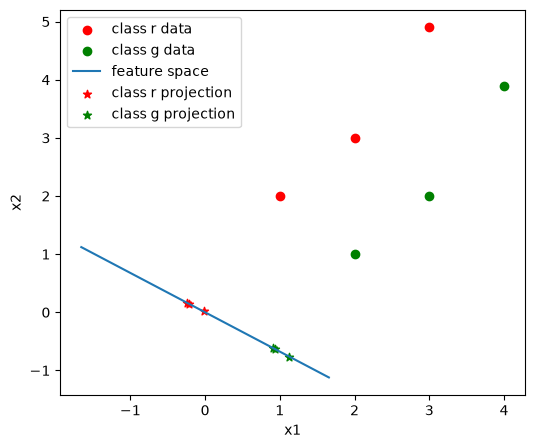

In [38]:
# visualize the results

# plot original data by classes
plt.figure(figsize=(6,5))
plt.scatter(X_1[:,0],X_1[:,1],c='r') # plot class 1 data points as read dots
plt.scatter(X_2[:,0],X_2[:,1],c='g') # plot class 2 data points as green dots
plt.xlabel('x1')
plt.ylabel('x2')

#plot transformed data by classes
plt.plot((-2*v[0],2*v[0]),(-2*v[1],2*v[1])) # plot a line representing the direction of v (it passes through the v and -v. The factor 2 extends the line wider) 
plt.scatter(X_tilde_1_cor[:,0],X_tilde_1_cor[:,1],c='r',marker='*') # plot the projection of class 1 data points on v as red stars
plt.scatter(X_tilde_2_cor[:,0],X_tilde_2_cor[:,1],c='g',marker='*') # plot the projection of class 2 data points on v as red stars
plt.legend(['class r data', 'class g data', 'feature space','class r projection','class g projection'])
plt.show();

## Overview of Feature Extraction and Dimensionality-Reduction Methods

In this learning module, we introduce PCA and LDA in detail, but there are many other methods for dimensionality reduction and feature extraction. This optional section uses the optical recognition of handwritten digits example to illustrate several of these methods and provide enrichment for students who want to explore further.

In [39]:
# Import required libraries

from sklearn import datasets
from sklearn.pipeline import make_pipeline # sequentially apply a list of transforms and a final estimator
from sklearn.preprocessing import StandardScaler # normalize data
from sklearn.model_selection import train_test_split # split data into training and testing data

### Optical Recognition of Handwritten Digits

Attributes (raw data columns): 64 pixel values from an $8 \times 8$ image. Values are integers in the range 0...16.

Class (target): the digit represented by the image, in the range 0...9.

In [40]:
# Load Digits dataset and take a look at the data description
digits = datasets.load_digits() #load data
print(digits.DESCR)


.. _digits_dataset:

Optical recognition of handwritten digits dataset
--------------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 1797
:Number of Attributes: 64
:Attribute Information: 8x8 image of integer pixels in the range 0..16.
:Missing Attribute Values: None
:Creator: E. Alpaydin (alpaydin '@' boun.edu.tr)
:Date: July; 1998

This is a copy of the test set of the UCI ML hand-written digits datasets
https://archive.ics.uci.edu/ml/datasets/Optical+Recognition+of+Handwritten+Digits

The data set contains images of hand-written digits: 10 classes where
each class refers to a digit.

Preprocessing programs made available by NIST were used to extract
normalized bitmaps of handwritten digits from a preprinted form. From a
total of 43 people, 30 contributed to the training set and different 13
to the test set. 32x32 bitmaps are divided into nonoverlapping blocks of
4x4 and the number of on pixels are counted in each block. This generates
an in

In [41]:

X_hd, y_hd = digits.data, digits.target #digits.data are features, digits.target is class (0,1,...,9)

# Parameters
obs, n_atr = X_hd.shape
print(f'The number of attributes is: {n_atr} \n')
print(f'The number of observation is: {obs} \n')
n_classes = len(np.unique(y_hd)) # number of classes
print(f'The number of classes is: {n_classes} \n')

random_state = 4 # to make the result replicable

# Split data (both features X and target y) into training and testing datasets. We use training data to learn parameters of feature extraction. We use test data to assess the performance of feature extraction
X_train, X_test, y_train, y_test = train_test_split(
                                                    X_hd, 
                                                    y_hd, 
                                                    test_size=0.2, 
                                                    stratify=y_hd,
                                                    random_state=random_state)

The number of attributes is: 64 

The number of observation is: 1797 

The number of classes is: 10 



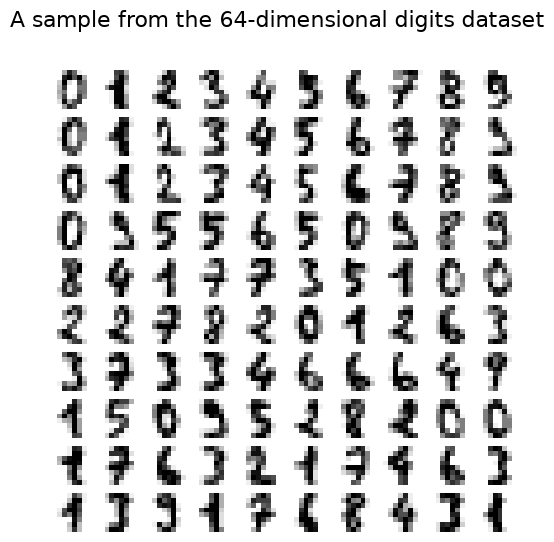

In [42]:
# visualize the first 100 data points of X
fig, axs = plt.subplots(nrows=10, ncols=10, figsize=(6, 6))
fig.suptitle("A sample from the 64-dimensional digits dataset", fontsize=16)
for idx, ax in enumerate(axs.ravel()): # idx is the index of data entries in X
    ax.imshow(X_hd[idx].reshape((8, 8)), cmap=plt.cm.binary) # reshape each entry, a vector of 64x1, into a 8x8 matrix. show the matrix as a grey-colored image
    ax.axis("off") # do not show axis of each image
plt.show();

### Matrix Decomposition Methods

The sklearn.decomposition module includes matrix decomposition algorithms, including among others PCA, Non-Negative Matrix Factorization (NMF) or ICA. Most of the algorithms of this module can be regarded as dimensionality reduction techniques.

https://scikit-learn.org/stable/api/sklearn.decomposition.html

In [43]:
from sklearn.decomposition import (PCA, IncrementalPCA, KernelPCA, 
                                   SparsePCA, TruncatedSVD, FastICA, 
                                   MiniBatchDictionaryLearning)

In [44]:
# Principal Component Analysis (PCA)
# Linear dimensionality reduction using Singular Value Decomposition of the
# data to project it to a lower dimensional space. The input data is centered
# but not scaled for each feature before applying the SVD.
# https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html#sklearn.decomposition.PCA
pca = make_pipeline(StandardScaler(),
                    PCA(n_components=2,
                        random_state=random_state))

In [45]:
# Incremental principal component analysis (IPCA) is typically used as a
# replacement for PCA when the dataset to be decomposed is too large to fit in
# memory. IPCA builds a low-rank approximation for the input data using an
# amount of memory which is independent of the number of input data samples.
# https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.IncrementalPCA.html#sklearn.decomposition.IncrementalPCA
inc_pca = make_pipeline(StandardScaler(with_std=False),
                        IncrementalPCA(n_components=2))

In [46]:
# KernelPCA is an extension of PCA which achieves non-linear dimensionality
# reduction through the use of kernels.
# kernel{‘linear’, ‘poly’, ‘rbf’, ‘sigmoid’, ‘cosine’, ‘precomputed’}, default=’linear’
# https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.KernelPCA.html
kpca = make_pipeline(StandardScaler(with_std=False),
                     KernelPCA(kernel="cosine",
                               n_components=2,
                               gamma=None,
                               fit_inverse_transform=True,
                               random_state=random_state,
                               n_jobs=1))

In [47]:
# SparsePCA is a variant of PCA, with the goal of extracting the set of sparse
# components that best reconstruct the data.
# https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.SparsePCA.html#sklearn.decomposition.SparsePCA
sparsepca = make_pipeline(StandardScaler(with_std=False),
                          SparsePCA(n_components=2,
                                    alpha=0.0001,
                                    random_state=random_state,
                                    n_jobs=-1))

In [48]:
# Dimensionality reduction using truncated SVD.
# This transformer performs linear dimensionality reduction by means of
# truncated singular value decomposition (SVD). Contrary to PCA, #
# this estimator does not center the data before computing the singular value
# decomposition. This means it can work with sparse matrices efficiently.
# https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.TruncatedSVD.html#sklearn.decomposition.TruncatedSVD
SVD = make_pipeline(StandardScaler(with_std=False),
                    TruncatedSVD(n_components=2,
                                 algorithm='randomized',
                                 random_state=random_state,
                                 n_iter=5))

In [49]:
# FastICA: a fast algorithm for Independent Component Analysis (ICA).
# ICA finds the independent components (also called factors, latent variables
# or sources) by maximizing the statistical independence of the estimated
# components.
# https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.FastICA.html#sklearn.decomposition.FastICA
FastICA = make_pipeline(StandardScaler(with_std=False),
                        FastICA(n_components=2,
                                algorithm = 'parallel',
                                max_iter = 100,
                                random_state=random_state))

In [50]:
# Minibatch Non-negative Matrix Factorization (Minibatch NMF)  finds two
# non-negative matrices, i.e. matrices with all non-negative elements,
# (W, H) whose product approximates the non-negative matrix X. This
# factorization can be used for various proposes including
# dimensionality reduction, source separation, or topic extraction.
# https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.MiniBatchNMF.html#sklearn.decomposition.MiniBatchNMF
miniBatchDictLearning = make_pipeline(StandardScaler(with_std=False),
                                      MiniBatchDictionaryLearning(n_components=2,
                                                                  batch_size = 10, #200
                                                                  alpha = 1,
                                                                  #n_iter = 25,
                                                                  random_state=random_state))

### Manifold Learning
Manifold learning is a class of unsupervised methods that seeks to describe datasets as low-dimensional manifolds embedded in high-dimensional spaces. Readers can review more methods using the link below.
https://scikit-learn.org/stable/modules/classes.html#module-sklearn.manifold

In [51]:
from sklearn.manifold import (Isomap,
                              LocallyLinearEmbedding)

In [52]:
# Isomap Embedding is non-linear dimensionality reduction through
# Isometric Mapping
# https://scikit-learn.org/stable/modules/generated/sklearn.manifold.Isomap.html#sklearn.manifold.Isomap
isomap = make_pipeline(StandardScaler(),
                       Isomap(n_components=2,
                              n_jobs = 4,
                              n_neighbors = 5))

In [53]:
# Locally linear embedding (LLE) seeks a lower-dimensional projection of the
# data which preserves distances within local neighborhoods. It can be thought
# of as a series of local PCAs which are globally compared to find the best
# non-linear embedding.
# https://scikit-learn.org/stable/modules/generated/sklearn.manifold.locally_linear_embedding.html#sklearn.manifold.locally_linear_embedding
lle = make_pipeline(LocallyLinearEmbedding(n_components=2,
                                           n_neighbors = 9,
                                           method = 'modified',
                                           n_jobs = 4,
                                           random_state=random_state))

### Discriminant Analysis Methods
Linear Discriminant Analysis and Quadratic Discriminant Analysis

https://scikit-learn.org/stable/modules/classes.html#module-sklearn.discriminant_analysis


In [54]:
from sklearn.discriminant_analysis import (LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis)

In [55]:
# Linear Discreminant Analysis (LDA) is a method to find a linear combination
# of features that characterizes or separates two or more classes of objects or
# events. Linear discriminant analysis is a supervised dimensionality reduction
# technique whereas PCA is unsupervised.  LDA finds a feature subspace that
# maximizes the separability between the groups.
# https://scikit-learn.org/stable/modules/generated/sklearn.discriminant_analysis.LinearDiscriminantAnalysis.html#sklearn.discriminant_analysis.LinearDiscriminantAnalysis
lda = make_pipeline(StandardScaler(),
                    LinearDiscriminantAnalysis(n_components=2))

In [56]:
# Quadratic Discriminant Analysis
# Quadratic Discriminant Analysis (QDA) is used to find a non-linear boundary
# between classes, whereas LDA finds a linear boundary between classes
# https://scikit-learn.org/stable/modules/generated/sklearn.discriminant_analysis.QuadraticDiscriminantAnalysis.html#sklearn.discriminant_analysis.QuadraticDiscriminantAnalysis
qda = make_pipeline(StandardScaler(),
                    QuadraticDiscriminantAnalysis())


### Random Projection Methods
Random projection implements a simple and computationally efficient way to reduce the dimensionality of data by trading a controlled amount of accuracy for faster processing and smaller model sizes. Two types of unstructured random matrices, Gaussian and sparse random matrices, are introduced below.

https://scikit-learn.org/stable/modules/classes.html#module-sklearn.random_projection

In [57]:
from sklearn.random_projection import (GaussianRandomProjection,
                                       SparseRandomProjection)

In [58]:
# Gaussian Random Projection
# The GaussianRandomProjection reduces the dimensionality by projecting the
# original input space on a randomly generated matrix where components are
# drawn from the following distribution N(0, 1 / n_components)
# https://scikit-learn.org/stable/modules/generated/sklearn.random_projection.GaussianRandomProjection.html#sklearn.random_projection.GaussianRandomProjection
GRP = make_pipeline(GaussianRandomProjection(n_components=2,
                                             eps = 0.5,
                                             random_state=random_state))

In [59]:
# Sparse Random Projection
# The SparseRandomProjection reduces the dimensionality by projecting the
# original input space using a sparse random matrix. It is an alternative to
# dense Gaussian random projection matrix that guarantees similar embedding
# quality while being much more memory efficient and allowing faster
# computation of the projected data. See the link below for detail.
# https://scikit-learn.org/stable/modules/random_projection.html#sparse-random-matrix
SRP = make_pipeline(SparseRandomProjection(n_components=2,
                                           density = 'auto',
                                           eps = 0.5,
                                           random_state=random_state,
                                           dense_output = False))

### Nearest-Neighbor Methods

sklearn.neighbors provides functionality for unsupervised and supervised neighbor-based learning methods. Unsupervised nearest neighbors form the foundation of many other learning methods, notably manifold learning and spectral clustering. Supervised neighbor-based learning comes in two forms: classification for data with discrete labels and regression for data with continuous labels.

https://scikit-learn.org/stable/modules/classes.html#module-sklearn.neighbors

In [60]:
from sklearn.neighbors import (KNeighborsClassifier,
                               NeighborhoodComponentsAnalysis)

In [61]:
# Neighborhood Components Analysis: a machine learning algorithm for metric
# learning. It learns a linear transformation in a supervised fashion to
# improve the classification accuracy of a stochastic nearest neighbors rule in
# the transformed space.
# https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.NeighborhoodComponentsAnalysis.html#sklearn.neighbors.NeighborhoodComponentsAnalysis
nca = make_pipeline(NeighborhoodComponentsAnalysis(n_components=2,
                                                   random_state=random_state))

In [62]:
# K Neighbors Classifier implements learning based on the nearest neighbors of
# each query point, where is an integer value specified by the user
# https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html#sklearn.neighbors.KNeighborsClassifier
n_neighbors=10
knn = KNeighborsClassifier(n_neighbors=n_neighbors)

### Comparison of Feature-Extraction Methods

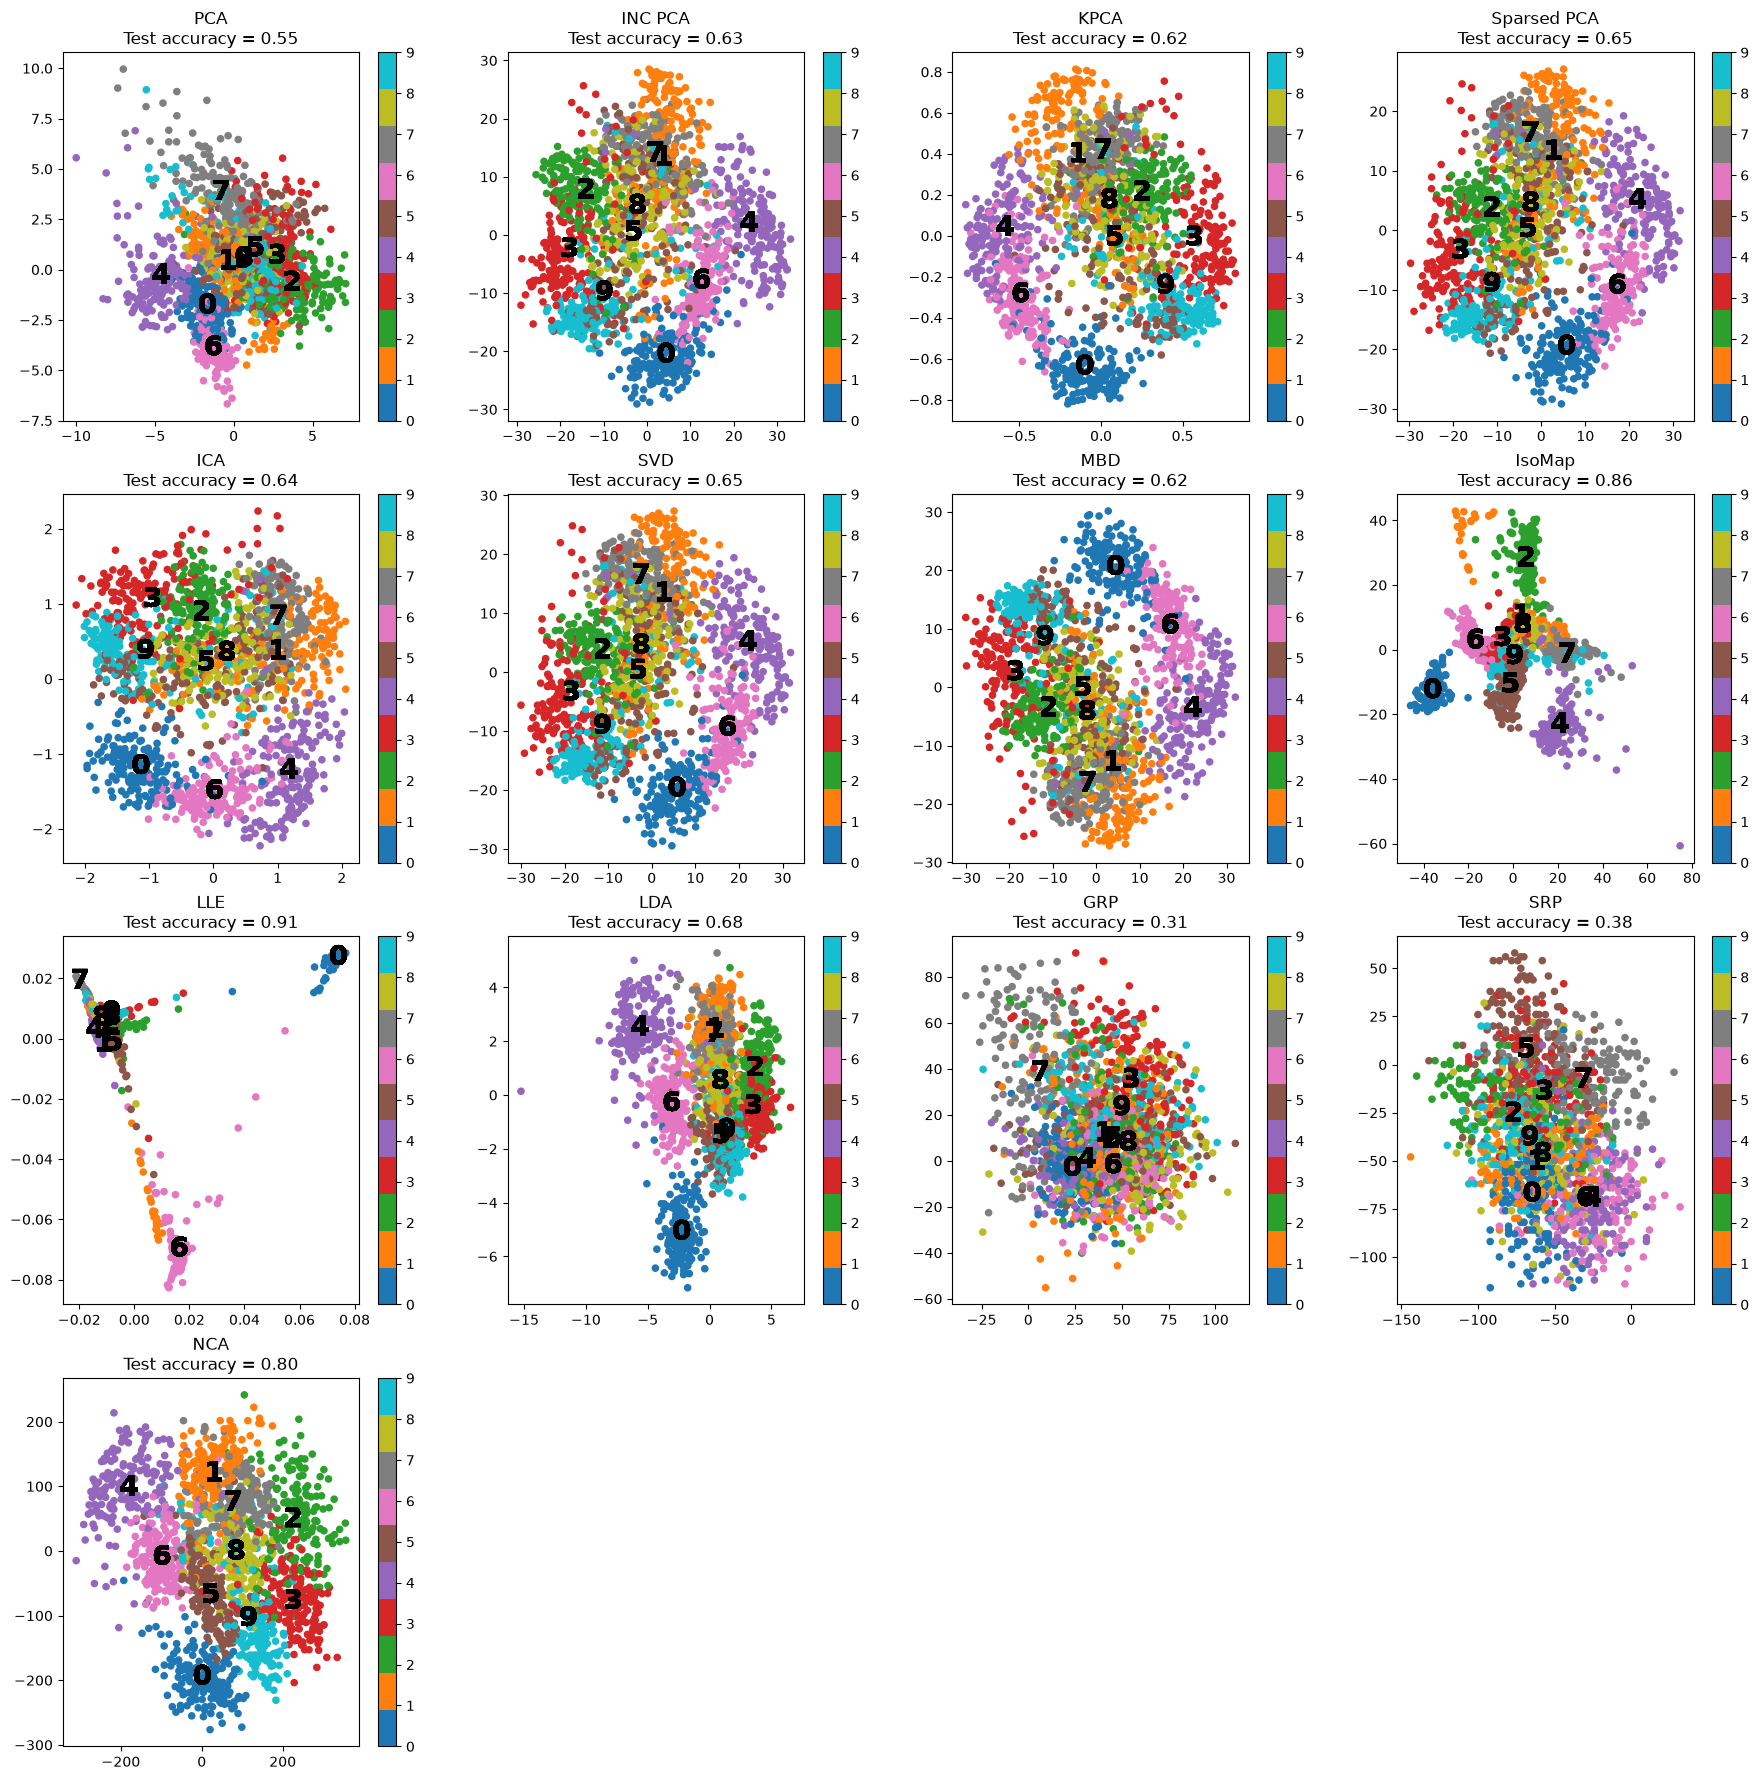

In [63]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd

# Make a list of the methods for comparison
feature_extraction_methods = {'PCA': pca, # Principal Component Analysis
                         'INC PCA': inc_pca, # Incremental PCA
                         'KPCA':kpca, # Kernel PCA
                         'Sparsed PCA': sparsepca, # Sparsed PCA
                         'ICA': FastICA, # Fast Independent Component Analysis
                         'SVD': SVD,  # Truncated SVD
                         'MBD': miniBatchDictLearning, # Minibatch Dictionary Learning
                         'IsoMap': isomap, # Isomap Embedding
                         'LLE': lle, # lower-dimensional projection
                         'LDA': lda, # Linear Discriminant Analysis
                         'GRP' : GRP, # Gausian Random Projection
                         'SRP': SRP, # Sparse Random Projection
                         'NCA': nca # Neighborhood Components Analysis
                         }


plt.figure(figsize=(22, 22))

for j,(name, model) in enumerate(feature_extraction_methods.items()):
    plt.subplot(4, 4, j + 1, aspect='auto')

    # Fit each method's model
    model.fit(X_train, y_train)

    # Fit a nearest neighbor classifier on the embedded training dataset (i.e., the extracted features). If the method extracts two high quality features, these should be good for classification
    knn.fit(model.transform(X_train), y_train) # fit an knn classifier using features extracted using a feature extraction method listed above

    # Compute the nearest neighbor accuracy on the embedded test dataset (i.e., the extracted fatures) to measure the method's quality for feature extraction.
    acc_knn = knn.score(model.transform(X_test), y_test) # test the ability of extracted features to perform the classification task on the test dataset

    # Extracted feature using the fitted model
    X_embedded = model.transform(X_hd)

    # Creating a dataframe to easily plot the sample label
    df = pd.DataFrame(np.concatenate((X_embedded, np.reshape(y_hd, (-1, 1))), axis=1)) #np.reshape(y,(-1,1)) means to reshape y into a column

    # Plot the projected points and show the evaluation score
    plt.scatter(X_embedded[:, 0], X_embedded[:, 1], c=y_hd, s=20, cmap='tab10')
    plt.title("{}".format(name))
    #plt.title("{}\nTest accuracy = {:.2f}".format(name,acc_knn))
    plt.title(f'{name}\nTest accuracy = {acc_knn:.2f}')
    plt.colorbar()

    # Label the data distributions
    for i, number in enumerate(y_test):
        plt.annotate(number,
                     df.loc[df[2]==number,[0,1]].mean(),
                     horizontalalignment='center',
                     verticalalignment='center',
                     weight='bold',
                     size='20')
plt.savefig('MethodComparison.png')
plt.show();